# Load Cleaned Data

Loading the cleaned dataset produced by `analysis.ipynb`. `StockCode` is forced back to string type, since CSVs don't preserve pandas dtypes on their own.

In [3]:
import pandas as pd

df = pd.read_csv("cleaned_retail_data.csv", parse_dates=["InvoiceDate"], dtype={"StockCode": str})
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%d-%m-%Y %H:%M")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


# Exploratory Data Analysis

## Monthly Revenue Trend

Looking at overall business trends over the two-year period — seasonality, growth, and any anomalies.

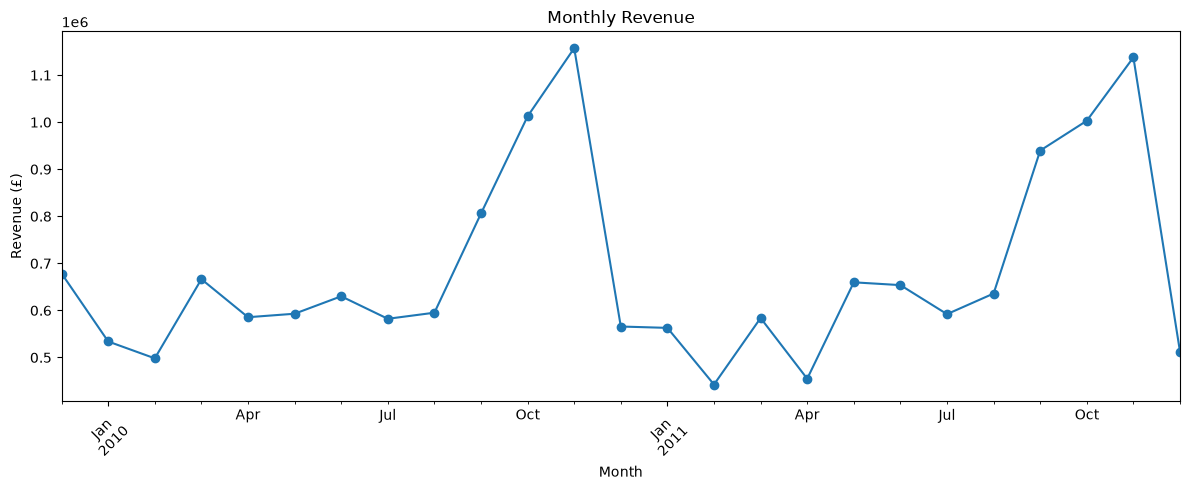

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly_revenue = df.groupby("InvoiceMonth")["TotalPrice"].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

## Top 10 Products by Revenue

Which individual products generate the most total revenue.

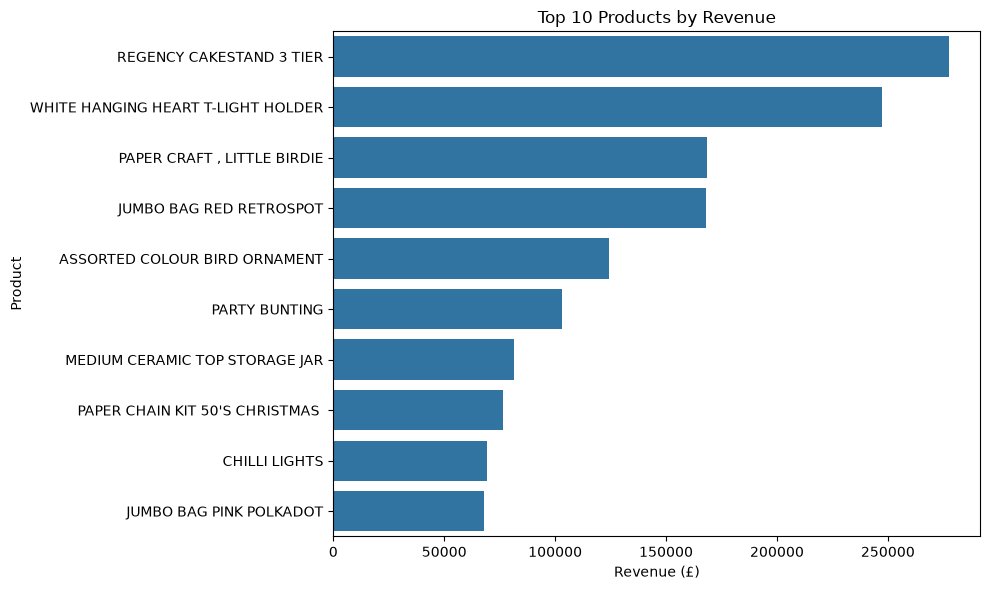

In [14]:
top_products = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, orient="h")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("top_products.png", dpi=150, bbox_inches="tight")
plt.show()

## Top 10 Countries by Revenue

How revenue is distributed geographically. As expected for a UK-based retailer, the UK dominates — worth keeping in mind when interpreting the customer segmentation later.

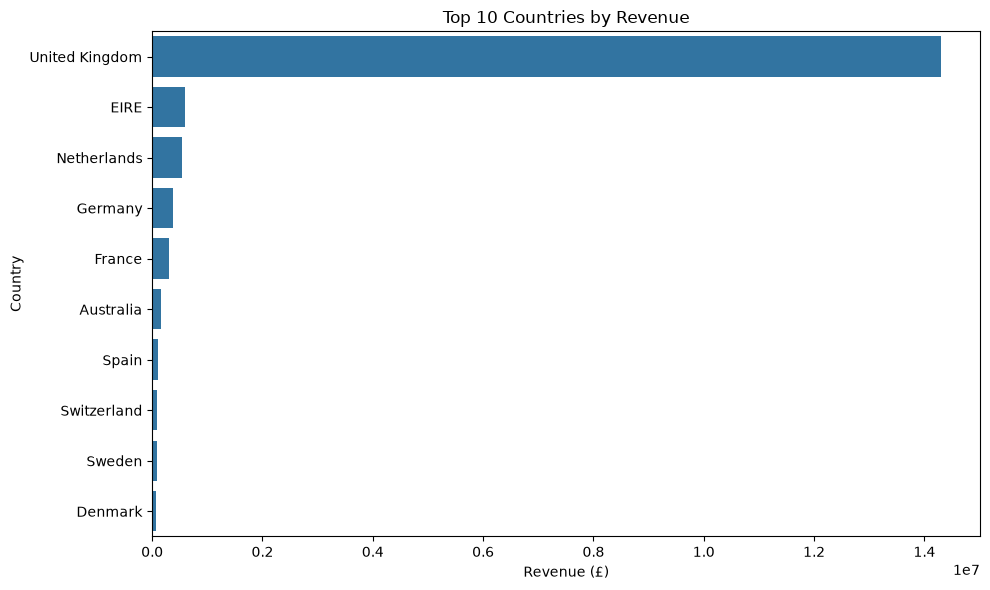

In [15]:
country_revenue = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_revenue.values, y=country_revenue.index, orient="h")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("top_countries.png", dpi=150, bbox_inches="tight")
plt.show()

# RFM Analysis

## Building the RFM Table

Calculating Recency (days since last purchase), Frequency (number of distinct orders), and Monetary (total spend) for every customer — the foundation of the segmentation.

In [4]:
import datetime as dt

snapshot_date = df["InvoiceDate"].max() + dt.timedelta(days=1)

rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,1658.40
12349,19,3,3678.69
12350,310,1,294.40


## Scoring Customers (R, F, M Quartiles)

Splitting each RFM metric into quartiles (1-4) so customers can be compared on a common scale, then combining them into a single RFM score.

In [5]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4])

rfm["RFM_Score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,
12346,326,12,77556.46,2,4,4,244
12347,2,8,4921.53,4,4,4,444
12348,75,5,1658.40,3,3,3,333
12349,19,3,3678.69,4,2,4,424
12350,310,1,294.40,2,1,1,211


## Mapping Scores to Segment Names

Translating the numeric R/F scores into business-friendly segment names (Champions, At Risk, Lost, etc.) using the standard RFM segmentation framework.

In [6]:
seg_map = {
    (4,4): 'Champions', (4,3): 'Loyal Customers', (4,2): 'Potential Loyalists', (4,1): 'New Customers',
    (3,4): 'Loyal Customers', (3,3): 'Loyal Customers', (3,2): 'Potential Loyalists', (3,1): 'Promising',
    (2,4): 'At Risk', (2,3): 'At Risk', (2,2): 'About to Sleep', (2,1): 'About to Sleep',
    (1,4): "Can't Lose", (1,3): "Can't Lose", (1,2): 'Hibernating', (1,1): 'Lost'
}

rfm['Segment'] = rfm.apply(lambda row: seg_map[(int(row['R_score']), int(row['F_score']))], axis=1)

rfm['Segment'].value_counts()

Segment
Loyal Customers        1286
About to Sleep          819
Lost                    762
Champions               755
At Risk                 650
Potential Loyalists     554
Hibernating             456
Promising               246
Can't Lose              235
New Customers            90
Name: count, dtype: int64

## Segment Size vs Revenue Contribution

Checking not just how many customers fall into each segment, but how much revenue each segment actually generates — this is where the real insight comes from.

In [7]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("Segment", "count"),
    Total_Revenue=("Monetary", "sum")
).sort_values("Total_Revenue", ascending=False)

segment_summary["Revenue_Share_%"] = (segment_summary["Total_Revenue"] / segment_summary["Total_Revenue"].sum() * 100).round(1)
segment_summary

,Customers,Total_Revenue,Revenue_Share_%
Segment,,,
Champions,755,9374766.495,54.9
Loyal Customers,1286,3721648.394,21.8
At Risk,650,1749399.823,10.2
Potential Loyalists,554,618237.401,3.6
About to Sleep,819,489306.092,2.9
Can't Lose,235,450041.861,2.6
Hibernating,456,307288.720,1.8
Lost,762,240996.692,1.4
Promising,246,101474.400,0.6


## Visualizing Customer Share vs Revenue Share

An interactive chart comparing what % of customers each segment represents against what % of revenue it generates.

In [ ]:
import plotly.express as px

segment_summary_reset = segment_summary.reset_index()
segment_summary_reset["Customer_Share_%"] = (segment_summary_reset["Customers"] / segment_summary_reset["Customers"].sum() * 100).round(1)

fig = px.bar(
    segment_summary_reset.melt(id_vars="Segment", value_vars=["Customer_Share_%", "Revenue_Share_%"]),
    x="Segment", y="value", color="variable", barmode="group",
    title="Customer Share vs Revenue Share by Segment",
    labels={"value": "Share (%)", "variable": ""}
)
fig.update_layout(xaxis_tickangle=-30)
fig.write_image("images/revenue_share.png", width=1000, height=600)
fig.show()

# Business Insights & Recommendations

## Key Findings

I grouped the retailer's ~5,900 customers into 10 segments using RFM (Recency, Frequency, Monetary) scoring, then checked how much revenue each segment actually contributes — not just how many customers are in it.

**The 80/20 pattern holds strongly here.** Champions make up just 12.9% of customers but generate 54.9% of total revenue. Losing even a handful of these customers would have an outsized impact on the business — they're worth protecting more than any other group.

**Not every large segment matters equally.** "About to Sleep" is the second-biggest group by customer count (819 people) but only accounts for 2.9% of revenue. Most of the customers going quiet were never big spenders to begin with — that changes how much a business should invest in winning them back.

**The segment worth real attention is "At Risk."** These 650 customers have already proven they're valuable (10.2% of revenue) but haven't purchased recently. Compared to Champions, they're a much better target for an active win-back campaign — you're not trying to convince a new customer to trust the brand, you're re-engaging someone who already has.

## Business Recommendations

- **Champions** — build a loyalty or VIP program. The cost of retaining this group is low relative to what's lost if they churn.
- **At Risk** — targeted win-back campaign (personalized email, limited-time discount) before recency slips further and they move into "Lost."
- **About to Sleep / Hibernating / Lost** (2,037 customers combined, ~6% of revenue) — low-cost automated re-engagement only; not worth a dedicated campaign given the low revenue contribution.
- **New Customers** — a structured onboarding/welcome series to convert first-time buyers into repeat, loyal customers before they go quiet.

## Methodology Note

Recency, Frequency, and Monetary values were calculated per customer, then split into quartiles to produce R, F, and M scores. Segments were labeled using the standard RFM segment mapping based on R and F scores, with Monetary value kept as supporting context per segment.